In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

# Load the prepared data from Notebook 2
X_train = np.load('../../data/models/X_train.npy')
X_test = np.load('../../data/models/X_test.npy')
y_train = np.load('../../data/models/y_train.npy')
y_test = np.load('../../data/models/y_test.npy')

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nTensorFlow version:", tf.__version__)
print("Ready to build model.")

X_train shape: (1592, 12, 4)
X_test shape: (399, 12, 4)
y_train shape: (1592,)
y_test shape: (399,)

TensorFlow version: 2.20.0
Ready to build model.


In [3]:
# Build the LSTM model
tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential([
    layers.Input(shape=(12, 4)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes: NORMAL, ELEVATED, CRITICAL
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape    ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ lstm (LSTM)            │ (None, 12, 64)  │    17,664 │
├────────────────────────┼─────────────────┼───────────┤
│ dropout (Dropout)      │ (None, 12, 64)  │         0 │
├────────────────────────┼─────────────────┼───────────┤
│ lstm_1 (LSTM)          │ (None, 32)      │    12,416 │
├────────────────────────┼─────────────────┼───────────┤
│ dropout_1 (Dropout)    │ (None, 32)      │         0 │
├────────────────────────┼─────────────────┼───────────┤
│ dense (Dense)          │ (None, 16)      │       528 │
├────────────────────────┼─────────────────┼───────────┤
│ dense_1 (Dense)        │ (None, 3)       │        51 │
└────────────────────────┴─────────────────┴───────────┘

 Total params: 30,659 (119.76 KB)

 Trainable params: 30,659 (119.76 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Class weights from Notebook 2
class_weight_dict = {0: 0.36, 1: 6.10, 2: 26.53}

# Early stopping — stops training if model stops improving
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete.")
print(f"Stopped at epoch: {len(history.history['loss'])}")

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8704 - loss: 0.3519 - val_accuracy: 0.6991 - val_loss: 0.8930
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9890 - loss: 0.1982 - val_accuracy: 0.6991 - val_loss: 0.7989
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9914 - loss: 0.1801 - val_accuracy: 0.6991 - val_loss: 0.8296
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9914 - loss: 0.1732 - val_accuracy: 0.6991 - val_loss: 0.8673
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9914 - loss: 0.1642 - val_accuracy: 0.6991 - val_loss: 0.8943
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9914 - loss: 0.1640 - val_accuracy: 0.6991 - val_loss: 0.8798
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9914 - loss: 0.1580 - val_accuracy: 0.6991 - val_loss: 0.9187
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9914 - loss: 0.1689 - val_accuracy: 0.

In [5]:
# Diagnose — what is the model actually predicting?
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Prediction distribution:")
unique, counts = np.unique(y_pred, return_counts=True)
for u, c in zip(unique, counts):
    label = ['NORMAL', 'ELEVATED', 'CRITICAL'][int(u)]
    print(f"  {int(u)} ({label}): {c} predictions")

print("\nActual distribution in test set:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    label = ['NORMAL', 'ELEVATED', 'Critical'][int(u)]
    print(f"  {int(u)} ({label}): {c} actual")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Prediction distribution:
  0 (NORMAL): 399 predictions

Actual distribution in test set:
  0 (NORMAL): 270 actual
  1 (ELEVATED): 113 actual
  2 (Critical): 16 actual


In [6]:
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn'], capture_output=True)
print("Done")

Done


In [7]:
from imblearn.over_sampling import SMOTE

# SMOTE works on 2D data so we reshape, oversample, then reshape back
X_train_2d = X_train.reshape(X_train.shape[0], -1)  # (1592, 48)

smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X_train_2d, y_train)

# Reshape back to 3D for LSTM
X_resampled = X_resampled.reshape(-1, 12, 4)

print("Before SMOTE:", X_train.shape, "| Labels:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After SMOTE: ", X_resampled.shape, "| Labels:", dict(zip(*np.unique(y_resampled, return_counts=True))))

Before SMOTE: (1592, 12, 4) | Labels: {np.int64(0): np.int64(1485), np.int64(1): np.int64(87), np.int64(2): np.int64(20)}
After SMOTE:  (4455, 12, 4) | Labels: {np.int64(0): np.int64(1485), np.int64(1): np.int64(1485), np.int64(2): np.int64(1485)}


In [8]:
# Rebuild and retrain with balanced data
tf.random.set_seed(42)
np.random.seed(42)

model2 = keras.Sequential([
    layers.Input(shape=(12, 4)),
    layers.LSTM(32, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(16, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop2 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history2 = model2.fit(
    X_resampled, y_resampled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop2],
    verbose=1
)

print("\nTraining complete.")
print(f"Stopped at epoch: {len(history2.history['loss'])}")

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6361 - loss: 0.8086 - val_accuracy: 0.1459 - val_loss: 0.9604
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7694 - loss: 0.5288 - val_accuracy: 0.5219 - val_loss: 0.9085
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7952 - loss: 0.5082 - val_accuracy: 0.5758 - val_loss: 0.7681
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8140 - loss: 0.4843 - val_accuracy: 0.5892 - val_loss: 0.7330
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8255 - loss: 0.4710 - val_accuracy: 0.5859 - val_loss: 0.7753
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8294 - loss: 0.4638 - val_accuracy: 0.6016 - val_loss: 0.7187
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8316 - loss: 0.4511 - val_accuracy: 0.6319 - val_loss: 0.6853
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8333 - loss: 0.4604 - val_acc

In [9]:
# Evaluate on real test data (not SMOTE data — original imbalanced test set)
y_pred2 = np.argmax(model2.predict(X_test), axis=1)

print("Prediction distribution:")
unique, counts = np.unique(y_pred2, return_counts=True)
for u, c in zip(unique, counts):
    label = ['NORMAL', 'ELEVATED', 'CRITICAL'][int(u)]
    print(f"  {int(u)} ({label}): {c} predictions")

print("\nActual distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    label = ['NORMAL', 'ELEVATED', 'CRITICAL'][int(u)]
    print(f"  {int(u)} ({label}): {c} actual")

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(y_test, y_pred2, 

SyntaxError: incomplete input (3896368963.py, line 19)

In [10]:
# Evaluate on real test data (not SMOTE data — original imbalanced test set)
y_pred2 = np.argmax(model2.predict(X_test), axis=1)

print("Prediction distribution:")
unique, counts = np.unique(y_pred2, return_counts=True)
for u, c in zip(unique, counts):
    label = ['NORMAL', 'ELEVATED', 'CRITICAL'][int(u)]
    print(f"  {int(u)} ({label}): {c} predictions")

print("\nActual distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    label = ['NORMAL', 'ELEVATED', 'CRITICAL'][int(u)]
    print(f"  {int(u)} ({label}): {c} actual")

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(y_test, y_pred2, 
      target_names=['NORMAL', 'ELEVATED', 'CRITICAL']))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Prediction distribution:
  0 (NORMAL): 264 predictions
  1 (ELEVATED): 60 predictions
  2 (CRITICAL): 75 predictions

Actual distribution:
  0 (NORMAL): 270 actual
  1 (ELEVATED): 113 actual
  2 (CRITICAL): 16 actual

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.89      0.90       270
    ELEVATED       0.50      0.27      0.35       113
    CRITICAL       0.12      0.56      0.20        16

    accuracy                           0.70       399
   macro avg       0.51      0.57      0.48       399
weighted avg       0.76      0.70      0.71       399



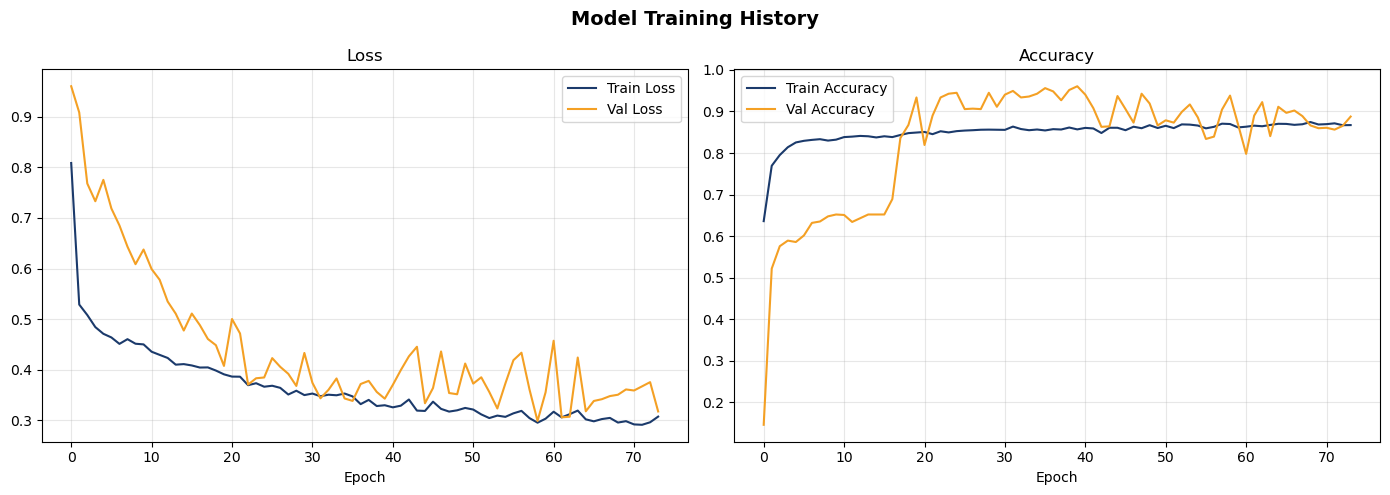

Model and plots saved.


In [11]:
# Save the trained model
model2.save('../../data/models/lstm_model.keras')

# Save training history plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=14, fontweight='bold')

ax1.plot(history2.history['loss'], label='Train Loss', color='#1B3A6B')
ax1.plot(history2.history['val_loss'], label='Val Loss', color='#F4A024')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history2.history['accuracy'], label='Train Accuracy', color='#1B3A6B')
ax2.plot(history2.history['val_accuracy'], label='Val Accuracy', color='#F4A024')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../data/models/training_history.png', dpi=150)
plt.show()
print("Model and plots saved.")

In [12]:
# Convert to TensorFlow Lite for deployment on Raspberry Pi
import tensorflow as tf

# Load the saved model
model_loaded = tf.keras.models.load_model('../../data/models/lstm_model.keras')

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_loaded)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Quantization — makes it smaller/faster
tflite_model = converter.convert()

# Save TFLite model
tflite_path = '../../data/models/lstm_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# Check file sizes
import os
keras_size = os.path.getsize('../../data/models/lstm_model.keras')
tflite_size = os.path.getsize(tflite_path)

print(f"Keras model size:  {keras_size / 1024:.1f} KB")
print(f"TFLite model size: {tflite_size / 1024:.1f} KB")
print(f"Size reduction:    {(1 - tflite_size/keras_size)*100:.1f}%")
print("\nTFLite model saved and ready for Pi deployment.")

INFO:tensorflow:Assets written to: C:\Users\blcas\AppData\Local\Temp\tmpbjk8947d\assets


INFO:tensorflow:Assets written to: C:\Users\blcas\AppData\Local\Temp\tmpbjk8947d\assets


Saved artifact at 'C:\Users\blcas\AppData\Local\Temp\tmpbjk8947d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 4), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1703914244624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940131152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940137680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940136528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940136912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940139024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940138448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940138064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940139408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940138640: TensorSpec(shape=(), dtype=tf.resource, name=None)


ConverterError: <unknown>:0: error: loc(callsite(fused["TensorListReserve:", "sequential_1_1/lstm_2_1/TensorArrayV2_1@__inference_function_58583"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_58634"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_58634"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: error: loc(callsite(fused["TensorListReserve:", "sequential_1_1/lstm_2_1/TensorArrayV2_1@__inference_function_58583"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_58634"] at fused["StatefulPartition

In [13]:
# Fix: enable Select TF ops for LSTM compatibility
converter = tf.lite.TFLiteConverter.from_keras_model(model_loaded)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

# Save TFLite model
tflite_path = '../../data/models/lstm_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

import os
keras_size = os.path.getsize('../../data/models/lstm_model.keras')
tflite_size = os.path.getsize(tflite_path)

print(f"Keras model size:  {keras_size / 1024:.1f} KB")
print(f"TFLite model size: {tflite_size / 1024:.1f} KB")
print("\nTFLite model saved and ready for Pi deployment.")

INFO:tensorflow:Assets written to: C:\Users\blcas\AppData\Local\Temp\tmpze_2l0bs\assets


INFO:tensorflow:Assets written to: C:\Users\blcas\AppData\Local\Temp\tmpze_2l0bs\assets


Saved artifact at 'C:\Users\blcas\AppData\Local\Temp\tmpze_2l0bs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 4), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1703914244624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940131152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940137680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940136528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940136912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940139024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940138448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940138064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940139408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1703940138640: TensorSpec(shape=(), dtype=tf.resource, name=None)
Keras model 

In [14]:
import os

# Use absolute path to be certain
base = r'C:\Users\blcas\Documents\radiation-defense-system\ml\data'

# Check what's actually in the data folder
print("Contents of ml/data:")
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{file}')

Contents of ml/data:
data/


In [15]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Define absolute base path
base = r'C:\Users\blcas\Documents\radiation-defense-system\ml\data'

# Create folders
os.makedirs(os.path.join(base, 'noaa_goes16_raw'), exist_ok=True)
os.makedirs(os.path.join(base, 'models'), exist_ok=True)

# Save model files
model2.save(os.path.join(base, 'models', 'lstm_model.keras'))

with open(os.path.join(base, 'models', 'lstm_model.tflite'), 'wb') as f:
    f.write(tflite_model)

# Save scaler
import pickle
with open(os.path.join(base, 'models', 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save numpy arrays
np.save(os.path.join(base, 'models', 'X_train.npy'), X_train)
np.save(os.path.join(base, 'models', 'X_test.npy'), X_test)
np.save(os.path.join(base, 'models', 'y_train.npy'), y_train)
np.save(os.path.join(base, 'models', 'y_test.npy'), y_test)

# Save training data CSV
df_full.to_csv(os.path.join(base, 'noaa_goes16_raw', 'training_data.csv'), index=False)

# Save training history plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=14, fontweight='bold')
ax1.plot(history2.history['loss'], label='Train Loss', color='#1B3A6B')
ax1.plot(history2.history['val_loss'], label='Val Loss', color='#F4A024')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(history2.history['accuracy'], label='Train Accuracy', color='#1B3A6B')
ax2.plot(history2.history

SyntaxError: incomplete input (2435025013.py, line 43)

In [16]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Define absolute base path
base = r'C:\Users\blcas\Documents\radiation-defense-system\ml\data'

# Create folders
os.makedirs(os.path.join(base, 'noaa_goes16_raw'), exist_ok=True)
os.makedirs(os.path.join(base, 'models'), exist_ok=True)

# Save model files
model2.save(os.path.join(base, 'models', 'lstm_model.keras'))

with open(os.path.join(base, 'models', 'lstm_model.tflite'), 'wb') as f:
    f.write(tflite_model)

# Save scaler
import pickle
with open(os.path.join(base, 'models', 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save numpy arrays
np.save(os.path.join(base, 'models', 'X_train.npy'), X_train)
np.save(os.path.join(base, 'models', 'X_test.npy'), X_test)
np.save(os.path.join(base, 'models', 'y_train.npy'), y_train)
np.save(os.path.join(base, 'models', 'y_test.npy'), y_test)

# Save training data CSV
df_full.to_csv(os.path.join(base, 'noaa_goes16_raw', 'training_data.csv'), index=False)

# Save training history plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=14, fontweight='bold')
ax1.plot(history2.history['loss'], label='Train Loss', color='#1B3A6B')
ax1.plot(history2.history['val_loss'], label='Val Loss', color='#F4A024')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(history2.history['accuracy'], label='Train Accuracy', color='#1B3A6B')
ax2.plot(history2.history['val_accuracy'], label='Val Accuracy', color='#F4A024')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base, 'models', 'training_history.png'), dpi=150)
plt.show()

print("Everything saved. Verifying...")
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{file}')

NameError: name 'scaler' is not defined

In [17]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Reload training data and recreate scaler
df_full = pd.read_csv(r'C:\Users\blcas\Documents\radiation-defense-system\ml\data\noaa_goes16_raw\training_data.csv')

feature_cols = ['proton_flux_10mev', 'speed', 'density', 'kp_index']
scaler = MinMaxScaler()
scaler.fit(df_full[feature_cols])

print("Scaler recreated.")
print("Now rerun the save cell above.")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\blcas\\Documents\\radiation-defense-system\\ml\\data\\noaa_goes16_raw\\training_data.csv'

Pulling NOAA data...
Training data saved: (2004, 6)
Scaler saved.
Arrays saved.
Models saved.


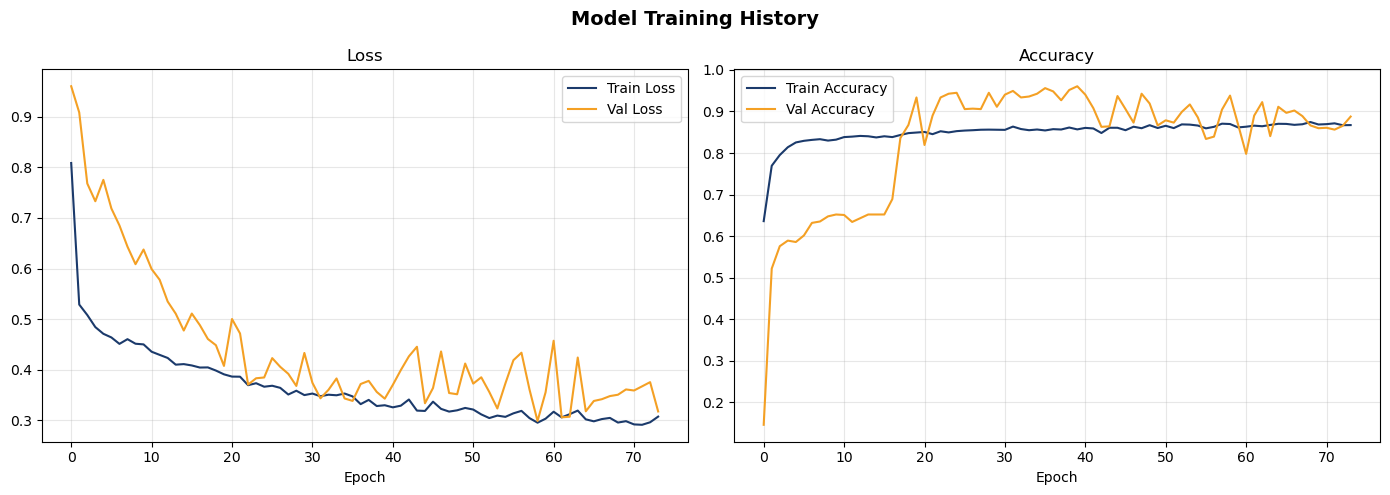

Plot saved.

Final directory contents:
data/
  models/
    lstm_model.keras
    lstm_model.tflite
    scaler.pkl
    training_history.png
    X_test.npy
    X_train.npy
    y_test.npy
    y_train.npy
  noaa_goes16_raw/
    training_data.csv


In [18]:
import requests
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.preprocessing import MinMaxScaler

base = r'C:\Users\blcas\Documents\radiation-defense-system\ml\data'
os.makedirs(os.path.join(base, 'noaa_goes16_raw'), exist_ok=True)
os.makedirs(os.path.join(base, 'models'), exist_ok=True)

# Re-pull NOAA data
print("Pulling NOAA data...")
df_protons = pd.DataFrame(requests.get(
    "https://services.swpc.noaa.gov/json/goes/primary/integral-protons-7-day.json"
).json())
df_protons['time_tag'] = pd.to_datetime(df_protons['time_tag'])
df_flux = df_protons[df_protons['energy'] == '>=10 MeV'][['time_tag','flux']].copy()
df_flux = df_flux.rename(columns={'flux': 'proton_flux_10mev'})
df_flux['time_tag'] = df_flux['time_tag'].dt.tz_localize(None)

df_plasma = pd.DataFrame(requests.get(
    "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"
).json())
df_plasma.columns = df_plasma.iloc[0]
df_plasma = df_plasma[1:].reset_index(drop=True)
df_plasma['time_tag'] = pd.to_datetime(df_plasma['time_tag']).dt.tz_localize(None)
df_plasma['speed'] = pd.to_numeric(df_plasma['speed'], errors='coerce')
df_plasma['density'] = pd.to_numeric(df_plasma['density'], errors='coerce')
df_plasma = df_plasma[['time_tag','speed','density']]

df_kp_full = pd.DataFrame(requests.get(
    "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json"
).json())
df_kp_full.columns = df_kp_full.iloc[0]
df_kp_full = df_kp_full[1:].reset_index(drop=True)
df_kp_full['time_tag'] = pd.to_datetime(df_kp_full['time_tag']).dt.tz_localize(None)
df_kp_full['Kp'] = pd.to_numeric(df_kp_full['Kp'], errors='coerce')
df_kp_clean = df_kp_full[['time_tag','Kp']].rename(columns={'Kp':'kp_index'})

# Merge
df_full = pd.merge_asof(df_flux.sort_values('time_tag'),
                        df_plasma.sort_values('time_tag'),
                        on='time_tag', direction='nearest')
df_full = pd.merge_asof(df_full.sort_values('time_tag'),
                        df_kp_clean.sort_values('time_tag'),
                        on='time_tag', direction='backward')
df_full = df_full.dropna().reset_index(drop=True)

# Add alert level
def classify_radiation(flux):
    if flux >= 0.4:
        return 2
    elif flux >= 0.25:
        return 1
    else:
        return 0

df_full['alert_level'] = df_full['proton_flux_10mev'].apply(classify_radiation)
df_full.to_csv(os.path.join(base, 'noaa_goes16_raw', 'training_data.csv'), index=False)
print(f"Training data saved: {df_full.shape}")

# Fit and save scaler
feature_cols = ['proton_flux_10mev', 'speed', 'density', 'kp_index']
scaler = MinMaxScaler()
scaler.fit(df_full[feature_cols])
with open(os.path.join(base, 'models', 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved.")

# Save numpy arrays
np.save(os.path.join(base, 'models', 'X_train.npy'), X_train)
np.save(os.path.join(base, 'models', 'X_test.npy'), X_test)
np.save(os.path.join(base, 'models', 'y_train.npy'), y_train)
np.save(os.path.join(base, 'models', 'y_test.npy'), y_test)
print("Arrays saved.")

# Save models
model2.save(os.path.join(base, 'models', 'lstm_model.keras'))
with open(os.path.join(base, 'models', 'lstm_model.tflite'), 'wb') as f:
    f.write(tflite_model)
print("Models saved.")

# Save training history plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=14, fontweight='bold')
ax1.plot(history2.history['loss'], label='Train Loss', color='#1B3A6B')
ax1.plot(history2.history['val_loss'], label='Val Loss', color='#F4A024')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(history2.history['accuracy'], label='Train Accuracy', color='#1B3A6B')
ax2.plot(history2.history['val_accuracy'], label='Val Accuracy', color='#F4A024')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(base, 'models', 'training_history.png'), dpi=150)
plt.show()
print("Plot saved.")

# Verify everything
print("\nFinal directory contents:")
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{file}')